Most fake review detection models are small-scale; you can run distributed anomaly detection across millions of users with Spark MLlib.
Big Data Components:

Aggregate by user → compute review frequency, rating variance, and text similarity.

Use clustering (K-Means, DBSCAN) to find suspicious review clusters.

Integrate graph analysis (Spark GraphX) to detect “review rings.”

Outcome:

A “Trust Index” for each reviewer or product, highlighting review manipulation at scale.

In [1]:
try:
    spark.stop()
except:
    pass


In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("CleanRestart")
    .config("spark.driver.memory", "3g")
    .config("spark.sql.shuffle.partitions", "32")
    .getOrCreate()
)
spark.range(5).show()


+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
+---+



In [3]:
!ls /home/jovyan/

EDA_AMAZON2.ipynb
meta.parquet
meta.parquet-20251009T224452Z-1-001.zip
reviews_eda_sample.parquet
reviews_eda_sample.parquet-20251009T224454Z-1-001.zip
work


In [5]:
!unzip /home/jovyan/reviews_eda_sample.parquet-20251009T224454Z-1-001.zip -d /home/jovyan/

Archive:  /home/jovyan/reviews_eda_sample.parquet-20251009T224454Z-1-001.zip
  inflating: /home/jovyan/reviews_eda_sample.parquet/_SUCCESS  
  inflating: /home/jovyan/reviews_eda_sample.parquet/.part-00082-aa2d54d7-28f6-4b2b-b4c6-041d18ed1db0-c000.snappy.parquet.crc  
  inflating: /home/jovyan/reviews_eda_sample.parquet/.part-00081-aa2d54d7-28f6-4b2b-b4c6-041d18ed1db0-c000.snappy.parquet.crc  
  inflating: /home/jovyan/reviews_eda_sample.parquet/.part-00074-aa2d54d7-28f6-4b2b-b4c6-041d18ed1db0-c000.snappy.parquet.crc  
  inflating: /home/jovyan/reviews_eda_sample.parquet/.part-00080-aa2d54d7-28f6-4b2b-b4c6-041d18ed1db0-c000.snappy.parquet.crc  
  inflating: /home/jovyan/reviews_eda_sample.parquet/part-00078-aa2d54d7-28f6-4b2b-b4c6-041d18ed1db0-c000.snappy.parquet  
  inflating: /home/jovyan/reviews_eda_sample.parquet/.part-00083-aa2d54d7-28f6-4b2b-b4c6-041d18ed1db0-c000.snappy.parquet.crc  
  inflating: /home/jovyan/reviews_eda_sample.parquet/.part-00076-aa2d54d7-28f6-4b2b-b4c6-041d18e

In [6]:
!unzip /home/jovyan/meta.parquet-20251009T224452Z-1-001.zip -d /home/jovyan/

Archive:  /home/jovyan/meta.parquet-20251009T224452Z-1-001.zip
  inflating: /home/jovyan/meta.parquet/.part-00004-7e66f8c9-9ea9-4d7a-9c82-3642e9c950df-c000.snappy.parquet.crc  
  inflating: /home/jovyan/meta.parquet/.part-00005-7e66f8c9-9ea9-4d7a-9c82-3642e9c950df-c000.snappy.parquet.crc  
  inflating: /home/jovyan/meta.parquet/.part-00006-7e66f8c9-9ea9-4d7a-9c82-3642e9c950df-c000.snappy.parquet.crc  
  inflating: /home/jovyan/meta.parquet/._SUCCESS.crc  
  inflating: /home/jovyan/meta.parquet/.part-00002-7e66f8c9-9ea9-4d7a-9c82-3642e9c950df-c000.snappy.parquet.crc  
  inflating: /home/jovyan/meta.parquet/_SUCCESS  
  inflating: /home/jovyan/meta.parquet/.part-00007-7e66f8c9-9ea9-4d7a-9c82-3642e9c950df-c000.snappy.parquet.crc  
  inflating: /home/jovyan/meta.parquet/.part-00014-7e66f8c9-9ea9-4d7a-9c82-3642e9c950df-c000.snappy.parquet.crc  
  inflating: /home/jovyan/meta.parquet/.part-00010-7e66f8c9-9ea9-4d7a-9c82-3642e9c950df-c000.snappy.parquet.crc  
  inflating: /home/jovyan/meta.par

In [4]:
reviews = spark.read.parquet("/home/jovyan/reviews_eda_sample.parquet")
print("Total sample reviews:", reviews.count())
print("Columns:", reviews.columns)
reviews.printSchema()


Total sample reviews: 2193853
Columns: ['asin', 'helpful_vote', 'images', 'parent_asin', 'rating', 'text', 'timestamp', 'title', 'user_id', 'verified_purchase']
root
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- attachment_type: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- small_image_url: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)



In [5]:
meta = spark.read.parquet("/home/jovyan/meta.parquet")
print("Total sample meta:", meta.count())
print("Columns:", meta.columns)
meta.printSchema()

Total sample meta: 1610012
Columns: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']
root
 |-- main_category: string (nullable = true)
 |-- title: string (nullable = true)
 |-- average_rating: double (nullable = true)
 |-- rating_number: long (nullable = true)
 |-- features: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- description: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- price: string (nullable = true)
 |-- images: struct (nullable = true)
 |    |-- hi_res: array (nullable = true)
 |    |    |-- element: string (containsNull = true)
 |    |-- large: array (nullable = true)
 |    |    |-- element: string (containsNull = true)
 |    |-- thumb: array (nullable = true)
 |    |    |-- element: string (containsNull = true)
 |    |-- variant: array (nullable = true)
 |

In [6]:
reviews = spark.read.parquet("/home/jovyan/reviews_eda_sample.parquet")
meta    = spark.read.parquet("/home/jovyan/meta.parquet")

In [7]:
reviews.show()

+----------+------------+------+-----------+------+--------------------+-------------+--------------------+--------------------+-----------------+
|      asin|helpful_vote|images|parent_asin|rating|                text|    timestamp|               title|             user_id|verified_purchase|
+----------+------------+------+-----------+------+--------------------+-------------+--------------------+--------------------+-----------------+
|B00F3F381A|           1|    []| B00HQBE8JU|   5.0|This compact pc i...|1405478902000|     NUC using Linux|AFQGD5XLVMGBLLOHS...|             true|
|B01GGKYN0A|           0|    []| B06W568Y6C|   5.0|Great product! Ch...|1559065336493|AmazonBasics USB ...|AEXBZC4LKKCXVJV7B...|             true|
|B00FJRS6QY|           0|    []| B00JO6RO8C|   1.0|I own multiple of...|1535465233923|            unusable|AGDXPL5XYW25IO3ZI...|             true|
|B007N4BX1Q|           0|    []| B0758HDGN8|   5.0|Item as described...|1507910183975|   100% recommended.|AH4JXSZYHFN

In [8]:
meta.show(10)

+--------------------+--------------------+--------------+-------------+----------------------+--------------------+-----+--------------------+------------+---------+--------------------+--------------------+-----------+---------------+--------+------+
|       main_category|               title|average_rating|rating_number|              features|         description|price|              images|      videos|    store|          categories|             details|parent_asin|bought_together|subtitle|author|
+--------------------+--------------------+--------------+-------------+----------------------+--------------------+-----+--------------------+------------+---------+--------------------+--------------------+-----------+---------------+--------+------+
|           Computers|igsticker Ultra T...|           4.3|           15|  [Perfectly fits a...|[Perfectly fits a...| None|{[https://m.media...|{[], [], []}|igsticker|[Electronics, Com...|{"Package Dimensi...| B07NZP44XR|           NULL|    N

In [9]:
from pyspark.sql import functions as F

# Join
joined = reviews.join(meta, on="parent_asin", how="left")

# Inspect schema to verify join success
print("Joined columns:", joined.columns[:15])
print("Total joined rows:", joined.count())

Joined columns: ['parent_asin', 'asin', 'helpful_vote', 'images', 'rating', 'text', 'timestamp', 'title', 'user_id', 'verified_purchase', 'main_category', 'title', 'average_rating', 'rating_number', 'features']
Total joined rows: 2193853


In [10]:
reviews_elec = joined.filter(
    (F.col("main_category") == "Electronics") |
    (F.array_contains(F.col("categories"), "Electronics"))
)
print("✅ Electronics-only reviews:", reviews_elec.count())


✅ Electronics-only reviews: 1978436


/tmp/ipykernel_479/862693638.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="rating", y="count", data=pdf_rating, palette="viridis")


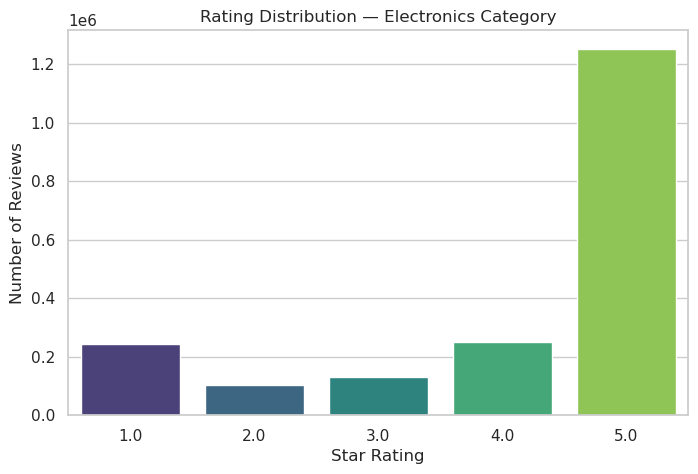

In [11]:
rating_counts = (
    reviews_elec.groupBy("rating").count().orderBy("rating")
)
pdf_rating = rating_counts.toPandas()

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

plt.figure(figsize=(8,5))
sns.barplot(x="rating", y="count", data=pdf_rating, palette="viridis")
plt.title("Rating Distribution — Electronics Category")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.show()


/tmp/ipykernel_479/821345200.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="verified_purchase", y="avg_rating", data=pdf_ver, palette="Set2")


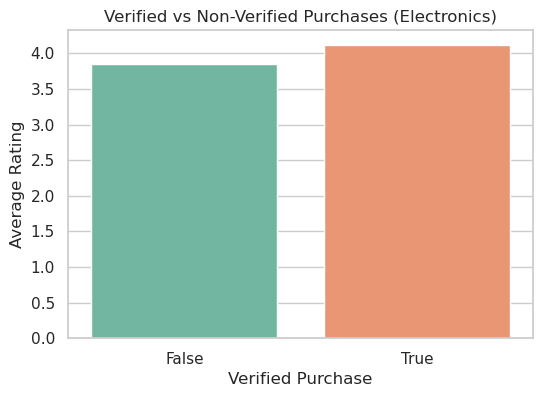

In [12]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

ver = reviews_elec.groupBy("verified_purchase").agg(
    F.avg("rating").alias("avg_rating")
).orderBy("verified_purchase")
pdf_ver = ver.toPandas()

plt.figure(figsize=(6,4))
sns.barplot(x="verified_purchase", y="avg_rating", data=pdf_ver, palette="Set2")
plt.title("Verified vs Non-Verified Purchases (Electronics)")
plt.xlabel("Verified Purchase")
plt.ylabel("Average Rating")
plt.show()


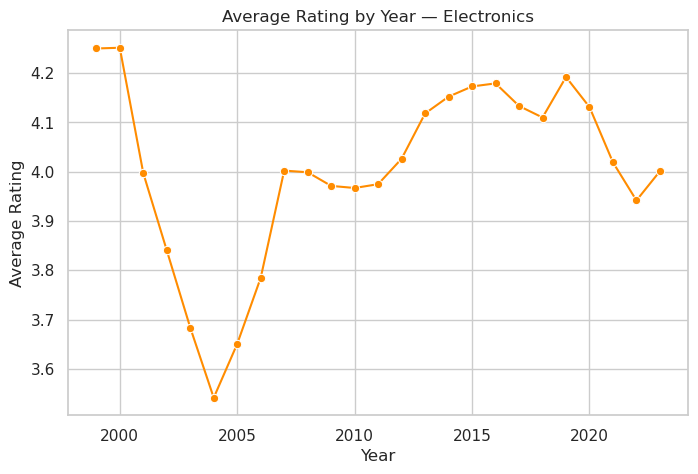

In [13]:
from pyspark.sql.functions import year, from_unixtime

reviews_elec = reviews_elec.withColumn(
    "year", year(from_unixtime(F.col("timestamp")/1000))
)

avg_by_year = (
    reviews_elec.groupBy("year")
    .agg(F.avg("rating").alias("avg_rating"))
    .orderBy("year")
)
pdf_year = avg_by_year.toPandas()

plt.figure(figsize=(8,5))
sns.lineplot(x="year", y="avg_rating", data=pdf_year, marker="o", color="darkorange")
plt.title("Average Rating by Year — Electronics")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.show()


/tmp/ipykernel_479/529209786.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="store", x="avg_rating", data=pdf_brands, palette="mako")


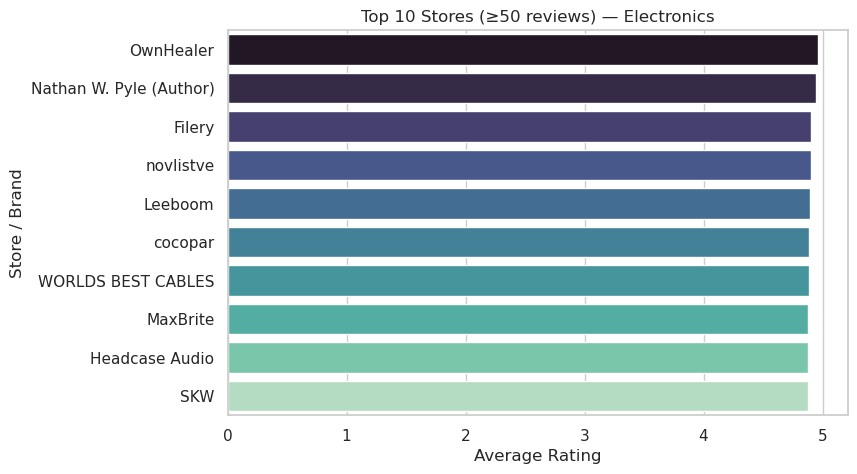

In [14]:
top_brands = (
    reviews_elec.groupBy("store")
    .agg(F.count("*").alias("n_reviews"), F.avg("rating").alias("avg_rating"))
    .filter(F.col("n_reviews") >= 50)
    .orderBy(F.desc("avg_rating"))
)

pdf_brands = top_brands.limit(10).toPandas()

plt.figure(figsize=(8,5))
sns.barplot(y="store", x="avg_rating", data=pdf_brands, palette="mako")
plt.title("Top 10 Stores (≥50 reviews) — Electronics")
plt.xlabel("Average Rating")
plt.ylabel("Store / Brand")
plt.show()


/tmp/ipykernel_479/1119993969.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="rating", y="avg_helpful", data=pdf_help, palette="crest")


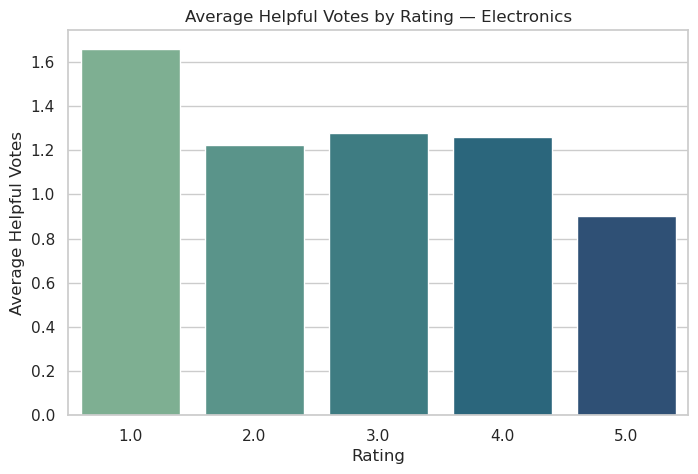

In [15]:
helpful = reviews_elec.groupBy("rating").agg(
    F.avg("helpful_vote").alias("avg_helpful")
).orderBy("rating")
pdf_help = helpful.toPandas()

plt.figure(figsize=(8,5))
sns.barplot(x="rating", y="avg_helpful", data=pdf_help, palette="crest")
plt.title("Average Helpful Votes by Rating — Electronics")
plt.xlabel("Rating")
plt.ylabel("Average Helpful Votes")
plt.show()


/tmp/ipykernel_479/4269097949.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="rating", y="avg_len", data=pdf_len, palette="coolwarm")


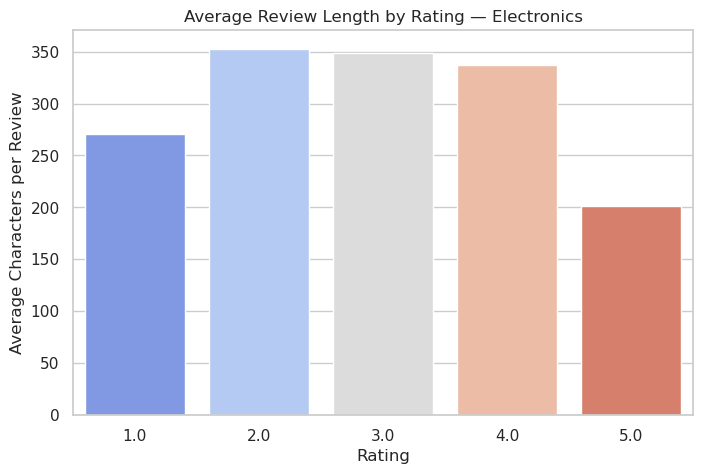

In [16]:
reviews_elec = reviews_elec.withColumn("review_len", F.length("text"))
avg_len = (
    reviews_elec.groupBy("rating")
    .agg(F.avg("review_len").alias("avg_len"))
    .orderBy("rating")
)
pdf_len = avg_len.toPandas()

plt.figure(figsize=(8,5))
sns.barplot(x="rating", y="avg_len", data=pdf_len, palette="coolwarm")
plt.title("Average Review Length by Rating — Electronics")
plt.xlabel("Rating")
plt.ylabel("Average Characters per Review")
plt.show()


In [17]:
!pip install textblob
from textblob import TextBlob
from pyspark.sql.types import DoubleType
from pyspark.sql.functions import udf

def get_sentiment(text):
    try:
        return TextBlob(text).sentiment.polarity
    except:
        return 0.0

sentiment_udf = udf(get_sentiment, DoubleType())
reviews_sent = reviews_elec.withColumn("sentiment", sentiment_udf(F.col("text")))


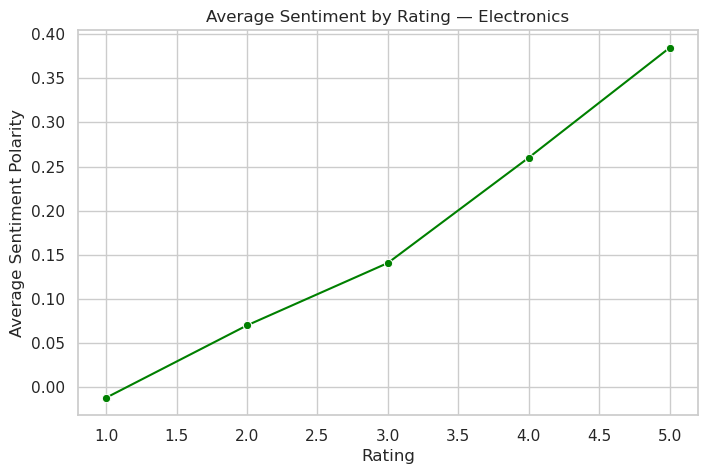

In [18]:
pdf_sent = (
    reviews_sent.groupBy("rating")
    .agg(F.avg("sentiment").alias("avg_sent"))
    .orderBy("rating")
    .toPandas()
)

plt.figure(figsize=(8,5))
sns.lineplot(x="rating", y="avg_sent", data=pdf_sent, marker="o", color="green")
plt.title("Average Sentiment by Rating — Electronics")
plt.xlabel("Rating")
plt.ylabel("Average Sentiment Polarity")
plt.show()


In [19]:
#Correlation between Amazon average rating and user rating
reviews_elec.stat.corr("average_rating", "rating")

0.24806038617151446

In [20]:
#Do longer reviews get more helpful votes?
reviews = reviews_elec.withColumn("review_len", F.length("text"))
reviews.groupBy("rating").agg(F.avg("helpful_vote"), F.avg("review_len")).show()


+------+------------------+-----------------+
|rating| avg(helpful_vote)|  avg(review_len)|
+------+------------------+-----------------+
|   4.0|1.2586295990078544|336.8904386745954|
|   3.0|1.2786914289675784|349.0778995694071|
|   1.0|1.6600373390167944|270.8404170074265|
|   5.0|0.9011276838972551|201.8172938141038|
|   2.0|1.2234226658975136|352.9011507963667|
+------+------------------+-----------------+



In [23]:
# Install VADER (if not installed)
!pip install nltk vaderSentiment

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from pyspark.sql import functions as F

an = SentimentIntensityAnalyzer()

# Create the UDF
udf_vader = F.udf(lambda t: float(an.polarity_scores(t or "")["compound"]), "double")

# Add the sentiment column PROPERLY
reviews_v = reviews_elec.withColumn("sent_vader", udf_vader("text"))

# Compute correlation
print("corr:", reviews_v.stat.corr("sent_vader", "rating"))


corr: 0.5469214193469153


In [21]:
#does price matter for products?
meta_price = meta.filter(F.col("price").rlike("^[0-9]+(\\.[0-9]+)?$"))\
                 .withColumn("price_num", F.col("price").cast("double"))
joined_price = reviews_elec.join(meta_price.select("parent_asin","price_num"), "parent_asin", "left")
joined_price.stat.corr("price_num", "rating")


0.0010869436099888274

In [22]:
#correlation between reviews and rating thus predicting popularity
popularity = (reviews_elec.groupBy("parent_asin")
              .agg(F.count("*").alias("n_reviews"),
                   F.avg("rating").alias("avg_rating")))
popularity.stat.corr("n_reviews", "avg_rating")


0.015679674570212715

In [23]:
#.sample(0.05, seed=42)
import pandas as pd, scipy.stats as stats
pdf = reviews_elec.select("verified_purchase","rating").toPandas()
v = pdf[pdf.verified_purchase == True]["rating"]
nv = pdf[pdf.verified_purchase == False]["rating"]
stats.ttest_ind(v, nv, equal_var=False)

TtestResult(statistic=67.78719903900243, pvalue=0.0, df=176130.81372672398)

In [24]:
pdf_brand = (reviews_elec.groupBy("store","rating")
             .agg(F.count("*").alias("n"))
             .filter(F.col("n")>30)
             .toPandas())
# Then one-way ANOVA between selected brands


In [25]:
reviews = reviews.withColumn("review_len", F.length("text"))
reviews.groupBy("rating").agg(F.avg("helpful_vote"), F.avg("review_len")).show()


+------+------------------+-----------------+
|rating| avg(helpful_vote)|  avg(review_len)|
+------+------------------+-----------------+
|   4.0|1.2586295990078544|336.8904386745954|
|   3.0|1.2786914289675784|349.0778995694071|
|   1.0|1.6600373390167944|270.8404170074265|
|   5.0|0.9011276838972551|201.8172938141038|
|   2.0|1.2234226658975136|352.9011507963667|
+------+------------------+-----------------+



In [26]:
#correlation between helpful vote and rating
print (reviews.stat.corr("helpful_vote", "rating"))
#correlation between review length and helpful vote
print(reviews.stat.corr("review_len", "helpful_vote"))


-0.016931091391158573
0.1824413690741911


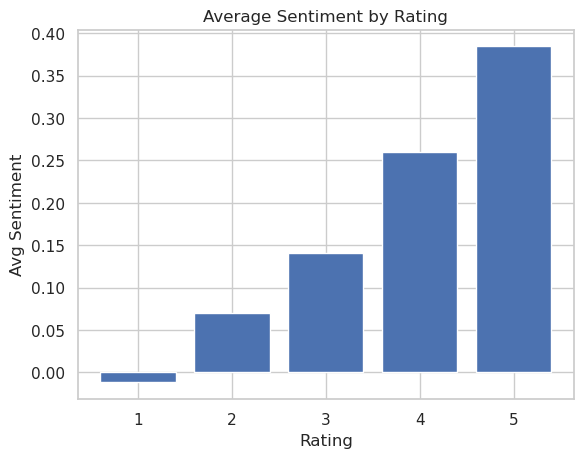

In [27]:
import matplotlib.pyplot as plt

pdf = reviews_sent.groupBy("rating").agg(F.avg("sentiment").alias("avg_sent")).toPandas()
plt.bar(pdf["rating"], pdf["avg_sent"])
plt.title("Average Sentiment by Rating")
plt.xlabel("Rating")
plt.ylabel("Avg Sentiment")
plt.show()


In [28]:
r = reviews.alias("r")
m = meta.alias("m")

joined = r.join(m, F.col("r.parent_asin") == F.col("m.parent_asin"), how="left")


In [29]:
joined = joined.drop(F.col("m.images"))


In [30]:
reviews_elec = joined.filter(
    (F.col("m.main_category") == "Electronics") |
    (F.array_contains(F.col("m.categories"), "Electronics"))
)


In [33]:
from pyspark.sql import functions as F
# Load the original Parquet again — NOT the already-joined variable
reviews_raw = spark.read.parquet("/home/jovyan/reviews_eda_sample.parquet")
# Prove we start clean
print("Number of columns:"
, len(reviews_raw.columns))

Number of columns: 10


In [35]:
from pyspark.sql import functions as F

reviews_clean = reviews_raw.select(
    "asin", "parent_asin", "rating", "helpful_vote",
    "verified_purchase", "text", "timestamp",
    F.col("images").alias("review_images")
)

# Add has_image flag
reviews_clean = reviews_clean.withColumn(
    "has_image", (F.size(F.col("review_images")) > 0).cast("int")
)
reviews_clean.select("review_images", "has_image").show(5, truncate=False)

+-------------+---------+
|review_images|has_image|
+-------------+---------+
|[]           |0        |
|[]           |0        |
|[]           |0        |
|[]           |0        |
|[]           |0        |
+-------------+---------+
only showing top 5 rows



In [36]:
print(reviews_raw.columns)
print(meta.columns)

['asin', 'helpful_vote', 'images', 'parent_asin', 'rating', 'text', 'timestamp', 'title', 'user_id', 'verified_purchase']
['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']


In [37]:
from pyspark.sql import functions as F

total = reviews_clean.count()
with_image = reviews_clean.filter(F.col("has_image") == 1).count()

print(f"Total reviews: {total:,}")
print(f"With images: {with_image:,}  ({with_image/total*100:.2f}% of total)")


Total reviews: 2,193,853
With images: 101,431  (4.62% of total)


/tmp/ipykernel_479/1510919531.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="has_image", y="num_reviews", data=img_stats, palette="crest")


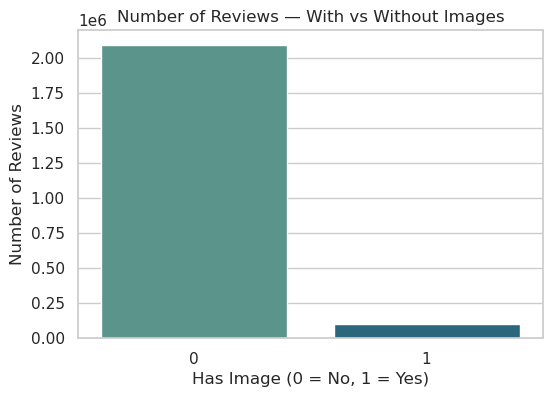

/tmp/ipykernel_479/1510919531.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="has_image", y="avg_rating", data=img_stats, palette="viridis")


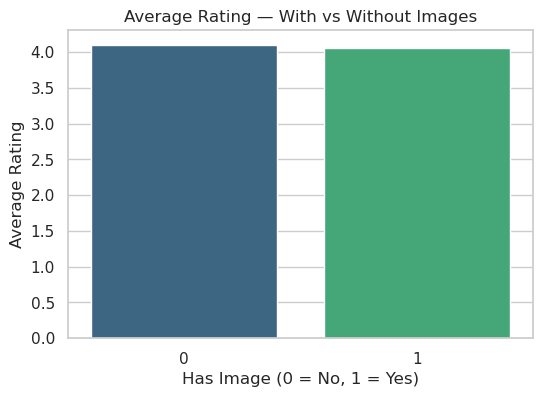

In [38]:
img_stats = (
    reviews_clean.groupBy("has_image")
    .agg(
        F.count("*").alias("num_reviews"),
        F.avg("rating").alias("avg_rating"),
        F.avg("helpful_vote").alias("avg_helpful")
    )
    .orderBy("has_image")
    .toPandas()
)

import seaborn as sns, matplotlib.pyplot as plt
sns.set(style="whitegrid")

plt.figure(figsize=(6,4))
sns.barplot(x="has_image", y="num_reviews", data=img_stats, palette="crest")
plt.title("Number of Reviews — With vs Without Images")
plt.xlabel("Has Image (0 = No, 1 = Yes)")
plt.ylabel("Number of Reviews")
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(x="has_image", y="avg_rating", data=img_stats, palette="viridis")
plt.title("Average Rating — With vs Without Images")
plt.xlabel("Has Image (0 = No, 1 = Yes)")
plt.ylabel("Average Rating")
plt.show()


In [39]:
from scipy import stats

pdf_img = (
    reviews_clean.select("has_image", "helpful_vote")
        .dropna(subset=["has_image", "helpful_vote"])
        .sample(fraction=0.05, seed=42)
        .toPandas()
)

# make sure both groups exist
print(pdf_img["has_image"].value_counts())

# correct usage
img_yes = pdf_img.loc[pdf_img["has_image"] == 1, "helpful_vote"]
img_no  = pdf_img.loc[pdf_img["has_image"] == 0, "helpful_vote"]

tstat2, pval2 = stats.ttest_ind(img_yes, img_no, equal_var=False)
print(f"[Test B] Helpful votes (Has image vs No image): "
      f"t = {tstat2:.3f}, p = {pval2:.3g}, "
      f"means = ({img_yes.mean():.3f} vs {img_no.mean():.3f}), "
      f"n = ({len(img_yes)} vs {len(img_no)})")


has_image
0    104262
1      5037
Name: count, dtype: int64
[Test B] Helpful votes (Has image vs No image): t = 7.311, p = 3.07e-13, means = (3.456 vs 0.923), n = (5037 vs 104262)


In [40]:
from pyspark.sql import functions as F

# Keep only the text column, drop null/empty reviews
text_df = reviews_elec.select("text").filter(F.col("text").isNotNull() & (F.length(F.col("text")) > 0))
print("Rows with valid text:", text_df.count())


Rows with valid text: 1978313


In [41]:
from pyspark.sql import functions as F

# Make sure all numeric columns exist
cols = [c for c in ["rating", "helpful_vote", "review_len", "has_image",
                    "verified_purchase", "sentiment", "sent_vader"] if c in reviews_clean.columns]

# Convert booleans to int, drop nulls, and sample to keep it small
numeric_df = (
    reviews_clean
    .select([F.col(c).cast("double") for c in cols])
    .dropna()
    .sample(fraction=0.05, seed=42)
    .toPandas()
)
numeric_df.head()

,rating,helpful_vote,has_image,verified_purchase
0,5.0,0.0,0.0,1.0
1,1.0,4.0,0.0,1.0
2,5.0,0.0,0.0,1.0
3,5.0,0.0,0.0,1.0
4,1.0,0.0,0.0,1.0


In [42]:
corr_matrix = numeric_df.corr()
print(corr_matrix)


                     rating  helpful_vote  has_image  verified_purchase
rating             1.000000     -0.025310  -0.005030           0.060146
helpful_vote      -0.025310      1.000000   0.044948          -0.034913
has_image         -0.005030      0.044948   1.000000          -0.045016
verified_purchase  0.060146     -0.034913  -0.045016           1.000000


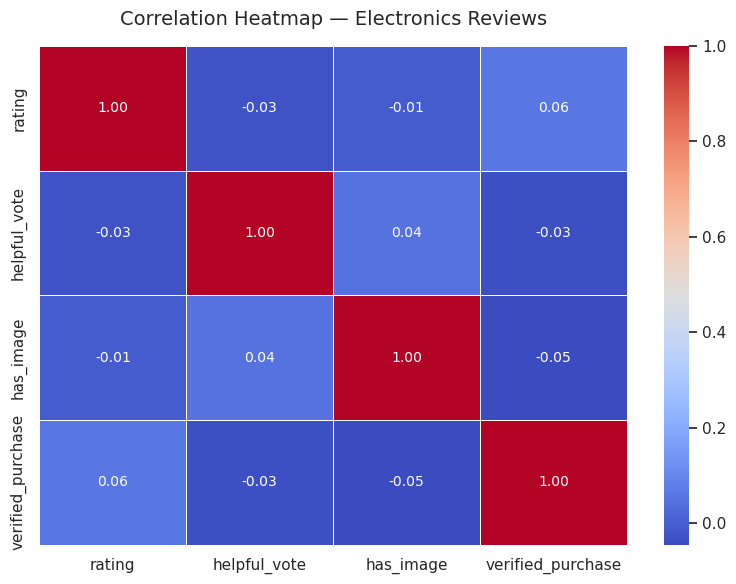

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size":10}
)
plt.title("Correlation Heatmap — Electronics Reviews", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


In [44]:
reviews_elec.columns

['parent_asin',
 'asin',
 'helpful_vote',
 'images',
 'rating',
 'text',
 'timestamp',
 'title',
 'user_id',
 'verified_purchase',
 'main_category',
 'title',
 'average_rating',
 'rating_number',
 'features',
 'description',
 'price',
 'images',
 'videos',
 'store',
 'categories',
 'details',
 'bought_together',
 'subtitle',
 'author',
 'year',
 'review_len',
 'main_category',
 'title',
 'average_rating',
 'rating_number',
 'features',
 'description',
 'price',
 'videos',
 'store',
 'categories',
 'details',
 'parent_asin',
 'bought_together',
 'subtitle',
 'author']

In [45]:
print("Review columns:", reviews.columns)
print("Count:", len(reviews.columns))

Review columns: ['parent_asin', 'asin', 'helpful_vote', 'images', 'rating', 'text', 'timestamp', 'title', 'user_id', 'verified_purchase', 'main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'bought_together', 'subtitle', 'author', 'year', 'review_len']
Count: 27


In [46]:
reviews = spark.read.parquet("/home/jovyan/reviews_eda_sample.parquet")

# Keep only the correct original columns
reviews = reviews.select(
    "asin",
    "helpful_vote",
    "images",           # only once
    "parent_asin",
    "rating",
    "text",
    "timestamp",
    "title",
    "user_id",
    "verified_purchase"
)

In [47]:
meta = spark.read.parquet("/home/jovyan/meta.parquet")

meta = meta.select(
    "parent_asin",
    "main_category",
    "title",
    "average_rating",
    "rating_number",
    "features",
    "description",
    "price",
    "store",
    "categories",
    "details",
    "bought_together",
    "subtitle",
    "author"
)

In [48]:
r = reviews.alias("r")
m = meta.alias("m")

joined = r.join(m, F.col("r.parent_asin") == F.col("m.parent_asin"), "left")

In [50]:
joined = joined.select(
    F.col("r.parent_asin").alias("parent_asin"),
    F.col("r.asin").alias("asin"),
    F.col("r.helpful_vote").alias("helpful_vote"),
    F.col("r.images").alias("review_images"),
    F.col("r.rating").alias("rating"),
    F.col("r.text").alias("text"),
    F.col("r.timestamp").alias("timestamp"),
    F.col("r.title").alias("review_title"),
    F.col("r.user_id").alias("user_id"),
    F.col("r.verified_purchase").alias("verified_purchase"),

    # meta
    "main_category",
    "average_rating",
    "rating_number",
    "price",
    "store",
    "categories",
    "details"
)

joined.printSchema()

root
 |-- parent_asin: string (nullable = true)
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- review_images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- attachment_type: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- small_image_url: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- review_title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- main_category: string (nullable = true)
 |-- average_rating: double (nullable = true)
 |-- rating_number: long (nullable = true)
 |-- price: string (nullable = true)
 |-- store: string (nullable = true)
 |-- categories: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- detai

In [51]:
reviews_elec1 = joined.filter(
    (F.col("main_category") == "Electronics") |
    (F.array_contains(F.col("categories"), "Electronics"))
)

In [52]:
reviews_elec1 = reviews_elec1.withColumn("review_len", F.length("text"))
reviews_elec1 = reviews_elec1.withColumn("helpful_log", F.log1p("helpful_vote"))
reviews_elec1 = reviews_elec1.withColumn("has_image", (F.size("review_images") > 0).cast("double"))
reviews_elec1 = reviews_elec1.withColumn("verified_purchase", F.col("verified_purchase").cast("double"))


In [54]:
reviews_elec1.columns

['parent_asin',
 'asin',
 'helpful_vote',
 'review_images',
 'rating',
 'text',
 'timestamp',
 'review_title',
 'user_id',
 'verified_purchase',
 'main_category',
 'average_rating',
 'rating_number',
 'price',
 'store',
 'categories',
 'details',
 'review_len',
 'helpful_log',
 'has_image']

In [55]:
from pyspark.sql import functions as F

df_km_input = reviews_elec1.select(
    F.col("rating").cast("double").alias("rating"),
    F.col("review_len").cast("double").alias("review_len"),
    F.col("helpful_log").cast("double").alias("helpful_log"),
    F.col("has_image").cast("double").alias("has_image"),
    F.col("verified_purchase").cast("double").alias("verified_purchase")
)

In [56]:
df_km_input = df_km_input.fillna(0)

df_km_input.printSchema()
df_km_input.show(5)

root
 |-- rating: double (nullable = false)
 |-- review_len: double (nullable = false)
 |-- helpful_log: double (nullable = false)
 |-- has_image: double (nullable = false)
 |-- verified_purchase: double (nullable = false)

+------+----------+-----------+---------+-----------------+
|rating|review_len|helpful_log|has_image|verified_purchase|
+------+----------+-----------+---------+-----------------+
|   3.0|      89.0|        0.0|      0.0|              1.0|
|   5.0|     106.0|        0.0|      0.0|              1.0|
|   4.0|      47.0|        0.0|      0.0|              1.0|
|   4.0|     221.0|        0.0|      0.0|              1.0|
|   5.0|     182.0|        0.0|      0.0|              0.0|
+------+----------+-----------+---------+-----------------+
only showing top 5 rows



In [57]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans

feature_cols = ["rating", "review_len", "helpful_log", "has_image", "verified_purchase"]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

df_vec = assembler.transform(df_km_input)

In [58]:
# Sample 5% for fast training
df_sample = df_vec.sample(0.05, seed=42)

print("Sample size:", df_sample.count())


Sample size: 98620


In [61]:
kmeans = KMeans(
    k=5,
    maxIter=10,
    seed=42,
    featuresCol="features",
    predictionCol="cluster"
)

km_model = kmeans.fit(df_sample)

print("KMeans model trained.")

KMeans model trained.


In [62]:
from pyspark.sql.types import DoubleType

# Apply model to full dataset
df_km = km_model.transform(df_vec)

# Extract centers
centers = km_model.clusterCenters()

# Distance UDF
dist_udf = F.udf(
    lambda c, v: float(v.squared_distance(centers[int(c)])) ** 0.5,
    DoubleType()
)

df_km = df_km.withColumn("dist", dist_udf("cluster", "features"))

# Normalize distance into 0–1 score
dmin, dmax = df_km.agg(F.min("dist"), F.max("dist")).first()

df_km = df_km.withColumn(
    "suspicion_score",
    (F.col("dist") - dmin) / (dmax - dmin + 1e-9)
)

# Assign suspicion levels
df_km = df_km.withColumn(
    "suspicion_level",
    F.when(F.col("suspicion_score") < 0.70, 0)
     .when(F.col("suspicion_score") < 0.90, 1)
     .when(F.col("suspicion_score") < 0.97, 2)
     .otherwise(3)
)

df_km.select("rating", "review_len", "helpful_log", "has_image",
             "suspicion_score", "suspicion_level").show(10)

+------+----------+------------------+---------+--------------------+---------------+
|rating|review_len|       helpful_log|has_image|     suspicion_score|suspicion_level|
+------+----------+------------------+---------+--------------------+---------------+
|   3.0|      89.0|               0.0|      0.0|0.002217015234417...|              0|
|   5.0|     106.0|               0.0|      0.0|0.001167297796974...|              0|
|   4.0|      47.0|               0.0|      0.0|  0.0048093050538612|              0|
|   4.0|     221.0|               0.0|      0.0|0.005896313117722883|              0|
|   5.0|     182.0|               0.0|      0.0|0.003488980745259457|              0|
|   5.0|      13.0|               0.0|      0.0|  0.0069089388575368|              0|
|   5.0|      33.0|               0.0|      0.0|0.005674009965708714|              0|
|   2.0|     140.0|0.6931471805599453|      0.0|9.049153401455842E-4|              0|
|   5.0|      80.0|               0.0|      0.0|0.0027

In [63]:
df_km.select("suspicion_score").summary().show()

# Suspicion level counts
df_km.groupBy("suspicion_level").count().orderBy("suspicion_level").show()

+-------+--------------------+
|summary|     suspicion_score|
+-------+--------------------+
|  count|             1978436|
|   mean| 0.00653805274571341|
| stddev|0.007425496550204493|
|    min|                 0.0|
|    25%|0.002710343240512392|
|    50%|0.005279073195853837|
|    75%| 0.00737965262812902|
|    max|  0.9999999999999383|
+-------+--------------------+

+---------------+-------+
|suspicion_level|  count|
+---------------+-------+
|              0|1978431|
|              1|      4|
|              3|      1|
+---------------+-------+



In [65]:
from pyspark.sql.functions import monotonically_increasing_id

# Add row index to original reviews_elec
reviews_elec_idx = reviews_elec1.withColumn("row_id", monotonically_increasing_id())

# Add same row index to df_km
df_km_idx = df_km.withColumn("row_id", monotonically_increasing_id())

# Join suspicion back to all metadata
df_final = reviews_elec_idx.join(df_km_idx, on="row_id", how="inner")

df_final = df_final.drop("row_id")

df_final.printSchema()
df_final.show(5)


root
 |-- parent_asin: string (nullable = true)
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- review_images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- attachment_type: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- small_image_url: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- review_title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: double (nullable = true)
 |-- main_category: string (nullable = true)
 |-- average_rating: double (nullable = true)
 |-- rating_number: long (nullable = true)
 |-- price: string (nullable = true)
 |-- store: string (nullable = true)
 |-- categories: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- detail

In [73]:
print(df_final.columns)
from collections import Counter
Counter(df_final.columns)

['parent_asin', 'asin', 'helpful_vote', 'review_images', 'rating', 'text', 'timestamp', 'review_title', 'user_id', 'verified_purchase', 'main_category', 'average_rating', 'rating_number', 'price', 'store', 'categories', 'details', 'review_len', 'helpful_log', 'has_image', 'rating', 'review_len', 'helpful_log', 'has_image', 'verified_purchase', 'features', 'cluster', 'dist', 'suspicion_score', 'suspicion_level']


Counter({'rating': 2,
         'verified_purchase': 2,
         'review_len': 2,
         'helpful_log': 2,
         'has_image': 2,
         'parent_asin': 1,
         'asin': 1,
         'helpful_vote': 1,
         'review_images': 1,
         'text': 1,
         'timestamp': 1,
         'review_title': 1,
         'user_id': 1,
         'main_category': 1,
         'average_rating': 1,
         'rating_number': 1,
         'price': 1,
         'store': 1,
         'categories': 1,
         'details': 1,
         'features': 1,
         'cluster': 1,
         'dist': 1,
         'suspicion_score': 1,
         'suspicion_level': 1})

In [76]:
from pyspark.sql.functions import monotonically_increasing_id, col

# Add row_id to both dataframes
reviews_elec_idx = reviews_elec1.withColumn("row_id", monotonically_increasing_id())
df_km_idx = df_km.withColumn("row_id", monotonically_increasing_id())

# Alias with prefixes to avoid confusion
r = reviews_elec_idx.alias("r")
k = df_km_idx.alias("k")

joined_full = r.join(k, on="row_id", how="inner")

In [77]:
df_final = joined_full.select(
    # === ORIGINAL REVIEW DATA (correct version) ===
    col("r.parent_asin").alias("parent_asin"),
    col("r.asin").alias("asin"),
    col("r.helpful_vote").alias("helpful_vote"),
    col("r.review_images").alias("review_images"),
    col("r.rating").alias("rating"),
    col("r.text").alias("text"),
    col("r.timestamp").alias("timestamp"),
    col("r.review_title").alias("review_title"),
    col("r.user_id").alias("user_id"),
    col("r.verified_purchase").alias("verified_purchase"),
    col("r.main_category").alias("main_category"),
    col("r.average_rating").alias("average_rating"),
    col("r.rating_number").alias("rating_number"),
    col("r.price").alias("price"),
    col("r.store").alias("store"),
    col("r.categories").alias("categories"),
    col("r.details").alias("details"),
    col("r.review_len").alias("review_len"),
    col("r.helpful_log").alias("helpful_log"),
    col("r.has_image").alias("has_image"),

    # === KMEANS OUTPUT (new columns) ===
    col("k.cluster").alias("cluster"),
    col("k.dist").alias("dist"),
    col("k.suspicion_score").alias("suspicion_score"),
    col("k.suspicion_level").alias("suspicion_level")
)


In [78]:
df_final = df_final.select(
    "parent_asin",
    "asin",
    "helpful_vote",
    "review_images",
    F.col("rating").alias("rating"),                  # from df_km
    "text",
    "timestamp",
    "review_title",
    "user_id",
    F.col("verified_purchase").alias("verified_purchase"), # from df_km
    "main_category",
    "average_rating",
    "rating_number",
    "price",
    "store",
    "categories",
    "details",
    F.col("review_len").alias("review_len"),          # cleaned
    F.col("helpful_log").alias("helpful_log"),        # cleaned
    F.col("has_image").alias("has_image"),            # cleaned
    "cluster",
    "dist",
    "suspicion_score",
    "suspicion_level"
)

In [81]:
df_final.printSchema()
from collections import Counter
Counter(df_final.columns)
print(df_final.count())

root
 |-- parent_asin: string (nullable = true)
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- review_images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- attachment_type: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- small_image_url: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- review_title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: double (nullable = true)
 |-- main_category: string (nullable = true)
 |-- average_rating: double (nullable = true)
 |-- rating_number: long (nullable = true)
 |-- price: string (nullable = true)
 |-- store: string (nullable = true)
 |-- categories: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- detail

1978436

In [82]:
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
import math

# Normalize helpfulness and length
stats = df_final.agg(
    F.max("helpful_log").alias("max_help"),
    F.max("review_len").alias("max_len")
).first()

max_help = stats["max_help"] or 1.0
max_len  = stats["max_len"] or 1.0

df_trust = df_final.withColumn("helpful_norm", F.col("helpful_log") / max_help)
df_trust = df_trust.withColumn("len_norm", F.col("review_len") / max_len)
df_trust = df_trust.withColumn("verified_d", F.col("verified_purchase").cast("double"))


In [83]:
def sigmoid_udf(x):
    return float(1 / (1 + math.exp(-x)))

sigmoid = F.udf(sigmoid_udf, DoubleType())

# weights (tune later if needed)
w_v = 1.0    # verified purchase
w_h = 0.7    # helpfulness
w_c = 1.5    # anti-suspicion
w_l = 0.5    # length
w_i = 0.3    # has_image

df_trust = df_trust.withColumn(
    "trust_base",
    w_v * F.col("verified_d") +
    w_h * F.col("helpful_norm") +
    w_c * (1 - F.col("suspicion_score")) +
    w_l * F.col("len_norm") +
    w_i * F.col("has_image")
)

df_trust = df_trust.withColumn("trust_review", sigmoid(F.col("trust_base")))


In [86]:
df_trust_sample = df_trust.sample(withReplacement=False, fraction=0.02, seed=42)
print("Sample size:", df_trust_sample.count())

Sample size: 39507


In [87]:
from pyspark.sql import functions as F

user_trust = (
    df_trust_sample.groupBy("user_id")
                   .agg(
                       F.count("*").alias("user_n_reviews"),
                       F.avg("trust_review").alias("trust_user")
                   )
)

In [88]:
item_trust = (
    df_trust_sample.groupBy("parent_asin")
                   .agg(
                       F.count("*").alias("item_n_reviews"),
                       F.avg("trust_review").alias("trust_item")
                   )
)

In [93]:
df_trust_sample = (
    df_trust_sample
    .join(user_trust, on="user_id", how="left")
    .join(item_trust, on="parent_asin", how="left")
)

In [95]:
df_trust_sample.select("suspicion_score").summary().show()

+-------+--------------------+
|summary|     suspicion_score|
+-------+--------------------+
|  count|               38170|
|   mean|0.006488444829958148|
| stddev|0.007033935393832814|
|    min|                 0.0|
|    25%|0.002648121252285323|
|    50%|0.005245152791845916|
|    75%|0.007341167461601275|
|    max| 0.21037922298806527|
+-------+--------------------+



In [96]:
df_trust_sample.groupBy("suspicion_level").count().orderBy("suspicion_level").show()


+---------------+-----+
|suspicion_level|count|
+---------------+-----+
|              0|38126|
+---------------+-----+



In [97]:
df_trust_sample.orderBy(F.col("suspicion_score").desc()) \
        .select("user_id", "parent_asin", "rating", "helpful_vote",
                "review_len", "has_image", "suspicion_score", 
                "suspicion_level", "text") \
        .show(10, truncate=120)

+----------------------------+-----------+------+------------+----------+---------+-------------------+---------------+------------------------------------------------------------------------------------------------------------------------+
|                     user_id|parent_asin|rating|helpful_vote|review_len|has_image|    suspicion_score|suspicion_level|                                                                                                                    text|
+----------------------------+-----------+------+------------+----------+---------+-------------------+---------------+------------------------------------------------------------------------------------------------------------------------+
|AHB4HT4JPEVDYG5WXGPIXT2EUPRQ| B0090B5E0Q|   5.0|           0|        17|      0.0|0.26278291447408864|              0|                                                                                                       These work great.|
|AGODBRAV57L3F5NGJEW55I3MZEKQ| B00XO

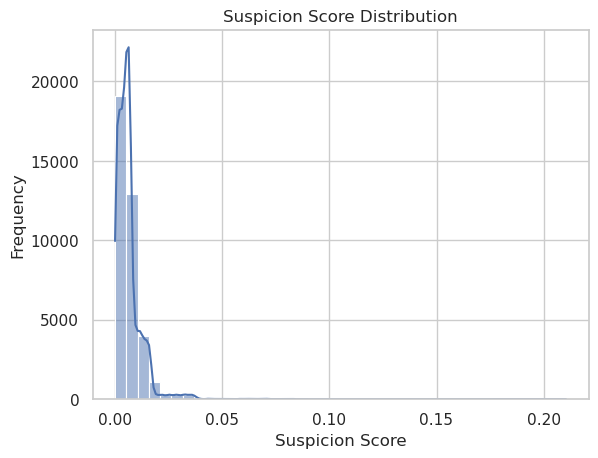

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

pdf = df_trust_sample.select("suspicion_score").toPandas()

sns.histplot(pdf["suspicion_score"], bins=40, kde=True)
plt.title("Suspicion Score Distribution")
plt.xlabel("Suspicion Score")
plt.ylabel("Frequency")
plt.show()

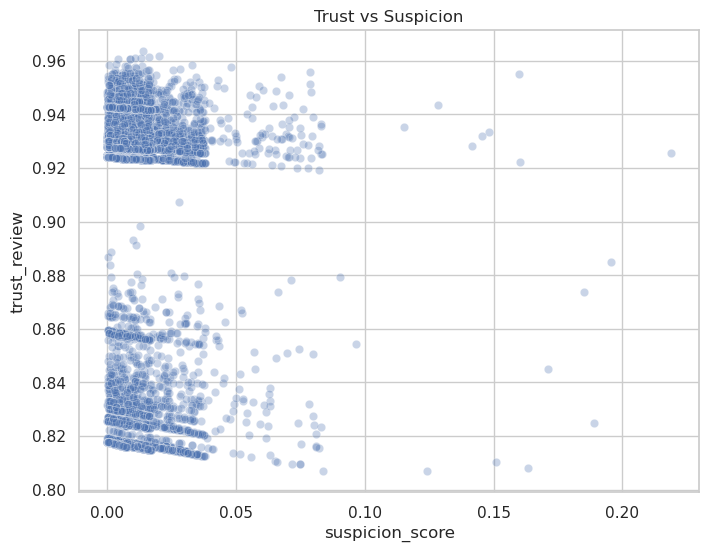

In [101]:
pdf2 = df_trust_sample.select("trust_review","suspicion_score").toPandas()

plt.figure(figsize=(8,6))
sns.scatterplot(x="suspicion_score", y="trust_review", data=pdf2, alpha=0.3)
plt.title("Trust vs Suspicion")
plt.show()

In [103]:
cluster_summary = df_trust_sample.groupBy("cluster").agg(
    F.count("*").alias("n"),
    F.avg("rating").alias("avg_rating"),
    F.avg("review_len").alias("avg_len"),
    F.avg("helpful_vote").alias("avg_help"),
    F.avg("verified_purchase").alias("verified_rate"),
    F.avg("suspicion_score").alias("mean_suspicion")
)

cluster_summary.orderBy("cluster").show(truncate=False)


+-------+-----+------------------+------------------+------------------+------------------+--------------------+
|cluster|n    |avg_rating        |avg_len           |avg_help          |verified_rate     |mean_suspicion      |
+-------+-----+------------------+------------------+------------------+------------------+--------------------+
|0      |32075|4.1494621979735   |150.79451286048325|0.6202338269680436|0.9384567420109119|0.005087640170692727|
|1      |768  |3.8190104166666665|1470.6471354166667|6.927083333333333 |0.7369791666666666|0.025468313108982957|
|2      |5    |4.4               |15339.0           |277.4             |0.6               |0.3713617743388512  |
|3      |112  |4.008928571428571 |3580.625          |20.651785714285715|0.6160714285714286|0.06020612610839355 |
|4      |5231 |3.834830816287517 |571.1969030778054 |2.4534505830625117|0.8327279678837698|0.011661244979534226|
+-------+-----+------------------+------------------+------------------+------------------+-----

In [104]:
suspicious_users = (
    df_trust_sample.groupBy("user_id")
            .agg(
                F.count("*").alias("n_reviews"),
                F.avg("suspicion_score").alias("avg_suspicion"),
                F.avg("trust_review").alias("avg_trust")
            )
            .filter("n_reviews >= 3")
            .orderBy(F.col("avg_suspicion").desc())
)

suspicious_users.show(20, truncate=False)

+----------------------------+---------+--------------------+------------------+
|user_id                     |n_reviews|avg_suspicion       |avg_trust         |
+----------------------------+---------+--------------------+------------------+
|AG3EKFK2QRKTVQTAVVCZNXZJELBA|3        |0.008856584030131754|0.9232274654778049|
|AHEZGDQ6WLA4ACH5Z456RDPLHREA|3        |0.006563236022596221|0.8535179106469061|
+----------------------------+---------+--------------------+------------------+



In [105]:
suspicious_items = (
    df_trust_sample.groupBy("parent_asin")
            .agg(
                F.count("*").alias("n_reviews"),
                F.avg("suspicion_score").alias("avg_suspicion"),
                F.avg("trust_review").alias("avg_trust")
            )
            .filter("n_reviews >= 10")
            .orderBy(F.col("avg_suspicion").desc())
)

suspicious_items.show(20, truncate=False)

+-----------+---------+--------------------+------------------+
|parent_asin|n_reviews|avg_suspicion       |avg_trust         |
+-----------+---------+--------------------+------------------+
|B0B3T4JWN9 |10       |0.012753977140804867|0.9171740986039539|
|B00E98O7GC |13       |0.012071015075822521|0.9247355955975205|
|B08739SDH3 |15       |0.01161418727428085 |0.8772805063683221|
|B0095PZHPE |15       |0.011327318199616541|0.9025444490257921|
|B07GXDLJP9 |13       |0.009652697137316412|0.893107236596906 |
|B092W3K376 |10       |0.009554789261231416|0.9281178077528068|
|B07BX4X77P |14       |0.009298380745847407|0.9248531004609609|
|B00FB50S0Q |13       |0.009091028650570576|0.9250500792448606|
|B07VHQW6F3 |10       |0.008939020796093222|0.9235739258092529|
|B0C3GSXJDJ |11       |0.008509437848191765|0.9149357642519635|
|B07CRSK5DM |10       |0.008453432496023046|0.9263562148182526|
|B0771VF9TJ |11       |0.008445397984495217|0.9082059636505907|
|B08V2MLHLN |12       |0.007906029950117

In [106]:
df_trust_sample.filter(F.col("suspicion_level") >= 2) \
        .select("user_id","parent_asin","rating",
                "helpful_vote","review_len","has_image",
                "verified_purchase","suspicion_score",
                "suspicion_level","trust_review","text") \
        .coalesce(1).write.option("header","true").mode("overwrite") \
        .csv("/home/jovyan/suspicious_reviews_export")

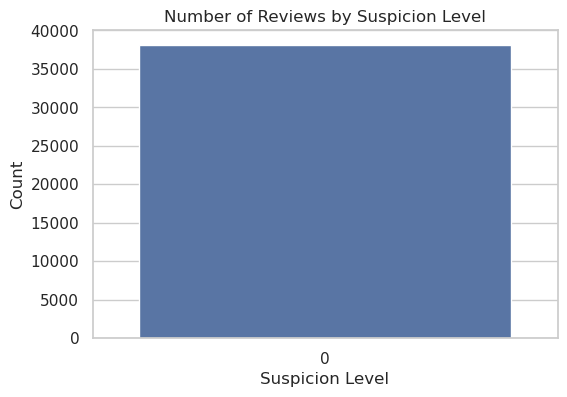

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

level_pdf = (
    df_trust_sample.groupBy("suspicion_level")
            .count()
            .orderBy("suspicion_level")
            .toPandas()
)

plt.figure(figsize=(6,4))
sns.barplot(data=level_pdf, x="suspicion_level", y="count")
plt.title("Number of Reviews by Suspicion Level")
plt.xlabel("Suspicion Level")
plt.ylabel("Count")
plt.show()

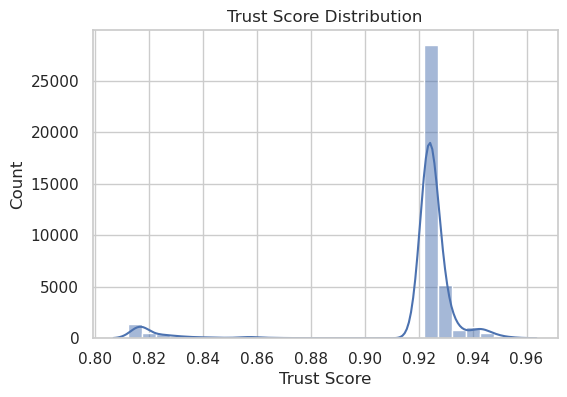

In [108]:
trust_pdf = df_trust_sample.select("trust_review").toPandas()

plt.figure(figsize=(6,4))
sns.histplot(trust_pdf["trust_review"], bins=30, kde=True)
plt.title("Trust Score Distribution")
plt.xlabel("Trust Score")
plt.ylabel("Count")
plt.show()

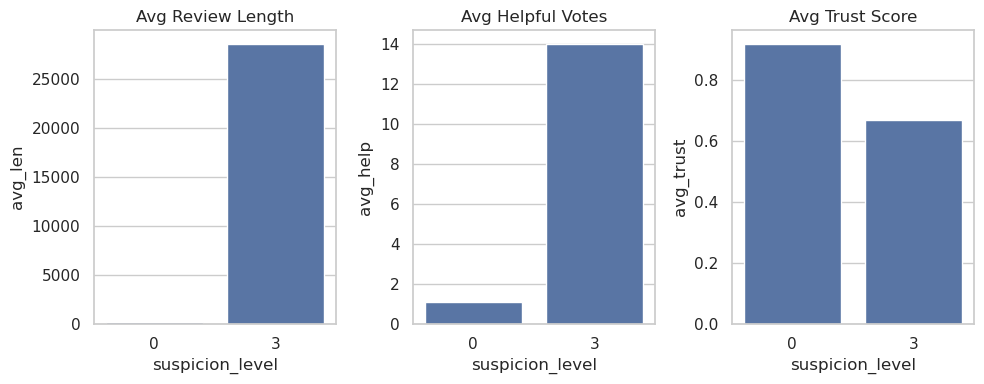

In [109]:
agg_pdf = (
    df_trust_sample.groupBy("suspicion_level")
            .agg(
                F.count("*").alias("n"),
                F.avg("rating").alias("avg_rating"),
                F.avg("review_len").alias("avg_len"),
                F.avg("helpful_vote").alias("avg_help"),
                F.avg("verified_purchase").alias("verified_rate"),
                F.avg("trust_review").alias("avg_trust"),
            )
            .orderBy("suspicion_level")
            .toPandas()
)

plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
sns.barplot(data=agg_pdf, x="suspicion_level", y="avg_len")
plt.title("Avg Review Length")

plt.subplot(1,3,2)
sns.barplot(data=agg_pdf, x="suspicion_level", y="avg_help")
plt.title("Avg Helpful Votes")

plt.subplot(1,3,3)
sns.barplot(data=agg_pdf, x="suspicion_level", y="avg_trust")
plt.title("Avg Trust Score")

plt.tight_layout()
plt.show()

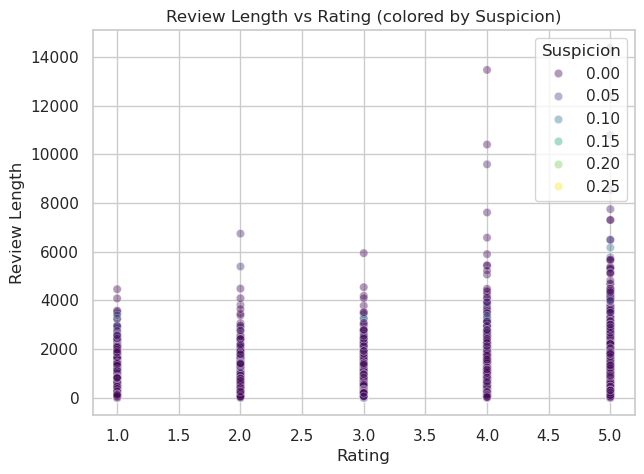

In [110]:
sc_pdf = df_trust_sample.select("rating", "review_len", "suspicion_score").toPandas()

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=sc_pdf,
    x="rating",
    y="review_len",
    hue="suspicion_score",
    palette="viridis",
    alpha=0.4
)
plt.title("Review Length vs Rating (colored by Suspicion)")
plt.xlabel("Rating")
plt.ylabel("Review Length")
plt.legend(title="Suspicion", loc="upper right")
plt.show()

In [111]:
cluster_pdf = (
    df_trust_sample.groupBy("cluster")
            .agg(
                F.count("*").alias("n"),
                F.avg("rating").alias("avg_rating"),
                F.avg("review_len").alias("avg_len"),
                F.avg("helpful_vote").alias("avg_help"),
                F.avg("suspicion_score").alias("avg_suspicion"),
                F.avg("trust_review").alias("avg_trust")
            )
            .orderBy("cluster")
            .toPandas()
)

cluster_pdf

,cluster,n,avg_rating,avg_len,avg_help,avg_suspicion,avg_trust
0,0,33104,4.152972,122.945445,0.478220,0.005083,0.919626
1,1,794,3.851385,1869.523929,7.866499,0.025013,0.901390
2,2,7,4.285714,15975.571429,235.285714,0.295660,0.872086
3,3,125,3.864000,4380.592000,24.864000,0.060163,0.885203
4,4,5458,3.748443,665.088860,2.809820,0.011787,0.910320


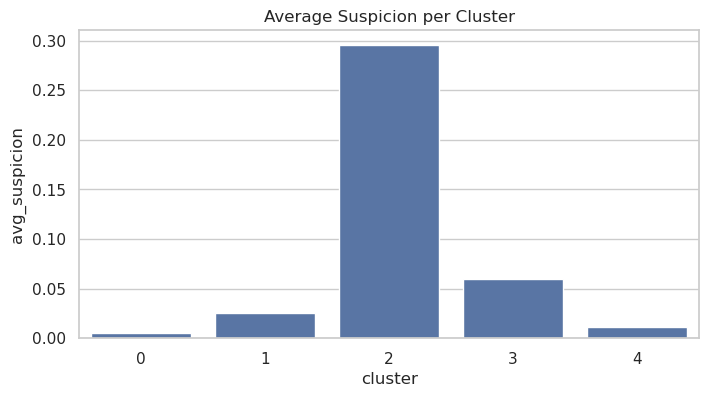

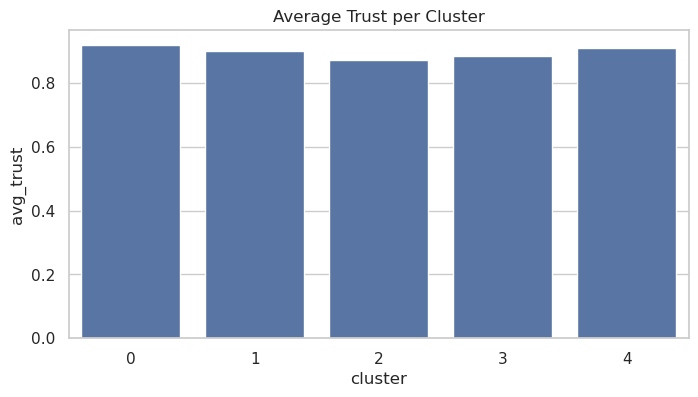

In [112]:
plt.figure(figsize=(8,4))
sns.barplot(data=cluster_pdf, x="cluster", y="avg_suspicion")
plt.title("Average Suspicion per Cluster")
plt.show()

plt.figure(figsize=(8,4))
sns.barplot(data=cluster_pdf, x="cluster", y="avg_trust")
plt.title("Average Trust per Cluster")
plt.show()

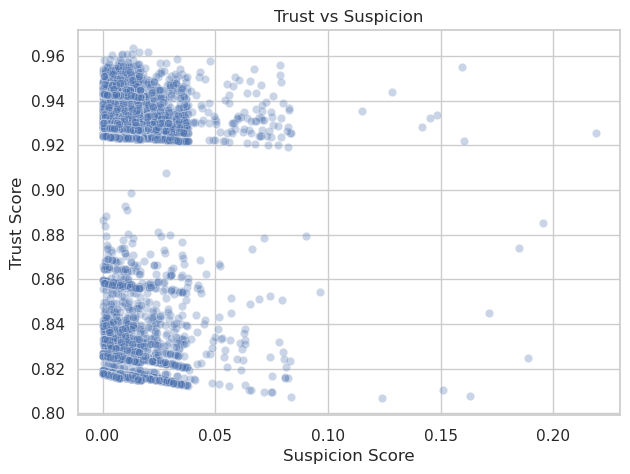

In [113]:
pdf2 = df_trust_sample.select("trust_review", "suspicion_score").toPandas()

plt.figure(figsize=(7,5))
sns.scatterplot(data=pdf2, x="suspicion_score", y="trust_review", alpha=0.3)
plt.title("Trust vs Suspicion")
plt.xlabel("Suspicion Score")
plt.ylabel("Trust Score")
plt.show()


In [114]:
from pyspark.ml.feature import PCA
from pyspark.ml.feature import VectorAssembler

# Use the SAME feature columns used for KMeans
feature_cols = ["rating", "review_len", "helpful_log", "has_image", "verified_purchase"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
df_vec = assembler.transform(df_final)

pca = PCA(k=2, inputCol="features_raw", outputCol="pca")
pca_model = pca.fit(df_vec)
df_pca = pca_model.transform(df_vec)

In [115]:
pca_sample = df_pca.select("pca", "cluster").sample(0.02, seed=42).toPandas()

# Extract 2D coordinates
pca_sample["x"] = pca_sample["pca"].apply(lambda v: float(v[0]))
pca_sample["y"] = pca_sample["pca"].apply(lambda v: float(v[1]))

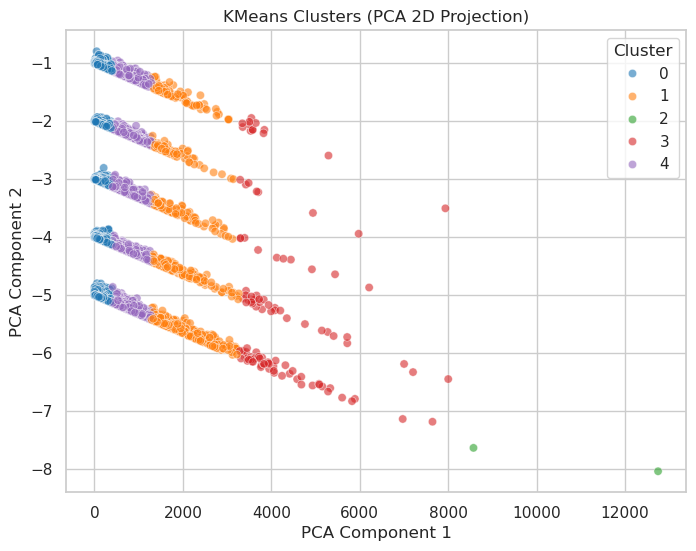

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_sample,
    x="x", y="y",
    hue="cluster",
    palette="tab10",
    alpha=0.6
)

plt.title("KMeans Clusters (PCA 2D Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()